# Random Sampling from Arbitrary Distributions (with `x^2` example)

There are multiple methods. We’ll cover the **Inverse-Transform** method, when you can integrate and invert the "CDF."   

Validation: We will obverlay histograms with "PDFs" to check our results.   
We work on the domain $[0,1]$.


![](random_pdf_slide1.png)

![](random_pdf_slide2.png)

#### Summary    

| Step |    What you do  |     Example (f(x)=3x²) |   
|-----------|-------------|---------------|
| 1 | Compute CDF $F(x)= \int f(x)\,dx$ | $x^3$ |
| 2 | Solve u=F(x) for x | $ x = u^{1/3}$ | 
| 3	| Draw u from U(0,1) | `u = np.random.rand(N)` |  
| 4	| Compute $x=F^{-1}(u)$ | $x = u^{1/3}$ |


The Kolmogorov–Smirnov (KS) test is one of the most widely used, simple, and general ways to compare a sample   
distribution to a reference distribution.   

**Intuitive Idea:**   The KS test measures how far apart the empirical CDF $F_n(x)$ and the reference CDF $F(x)$ are,   
everywhere along the x-axis.  For our example, $F_n(x)$ is what we get from drawing random numbers from $U(0,1)$. The   
reference CDF is $x^3$.

**KS Statistic**   
The KS statistic $D_n$ is the maximum vertical distance between the two CDFs:
$$
D_n = \max_{x} | F_n(x) -F(x)|
$$

Graphically, if you plot both CDFs, $D_n$ is the largest gap between them. If we did a good job, our $D_n$ is small.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(123)

def show_hist_with_pdf(samples, pdf, xgrid, bins=60, title="", domain=(0,1)):
    a,b = domain
    plt.figure(figsize=(6.0,4.0))
    # density=True normalizes histogram area to 1
    plt.hist(samples, bins=bins, range=domain, density=True, alpha=0.5, label="samples (hist)")
    plt.plot(xgrid, pdf(xgrid), lw=2, label="target pdf")
    plt.xlim(a,b)
    plt.xlabel("x")
    plt.ylabel("density")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def ks_test(samples, cdf):
    d, p = stats.kstest(samples, cdf)
    print(f"KS test: D = {d:.4f}, p = {p:.4f}  (higher p --> more consistent)")


## Example: $f(x)=3x^2$ on $[0,1]$

- PDF: $f(x)=3x^2$, normalized since $\int_0^1 3x^2\,dx = 1$.
- CDF: $F(x)=\int_0^x 3t^2\,dt = x^3$.
- Inverse CDF: $F^{-1}(u) = u^{1/3}$.

So inverse-transform sampling is simple here.


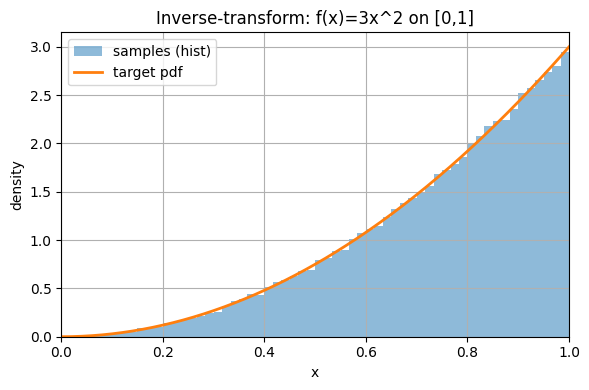

KS test: D = 0.0021, p = 0.7500  (higher p --> more consistent)


In [8]:
# target pdf/cdf for x^2 example
f = lambda x: 3.0*x**2
F = lambda x: x**3
Finv = lambda u: u**(1.0/3.0)

N = 100_000
u = rng.random(N)          # U(0,1)
x_inv = Finv(u)            # samples ~ 3x^2 on [0,1]

xgrid = np.linspace(0,1,400)
show_hist_with_pdf(x_inv, f, xgrid, title="Inverse-transform: f(x)=3x^2 on [0,1]")
ks_test(x_inv, F)


#### Exercises

**1.**  Consider the case where the PDF $\propto e^{-\lambda x}$. Pick a positive value of $\lambda$ and see   
if you can produce the PDF. Be sure your PDF is normalized: $\int {\text {PDF}}\,dx = 1$. 

**2.** Try to produce a PDF that is shaped like a quadratic, centered about $x=0$, and extends between $x =\pm2$.

**3.** Produce a power law PDF $\propto x^{-\alpha} \quad (x\ge 1)$. $\alpga >0$ and be sure to normalize your PDF.

In [ ]:
**4.** Good general probability problem. Consider a square of some side length $L$. Pick a random point on one side of   
the square and another on an adjacent side. Your positions should be uniformly random so that any position along the relevant   
sides is equally likely. What is the probability $P(l> L)$ that the distance between the two points $l$ exceeds $L$?   
This can be solved analytically but probably can be computed faster with code. We do not need fantastic precision.
    